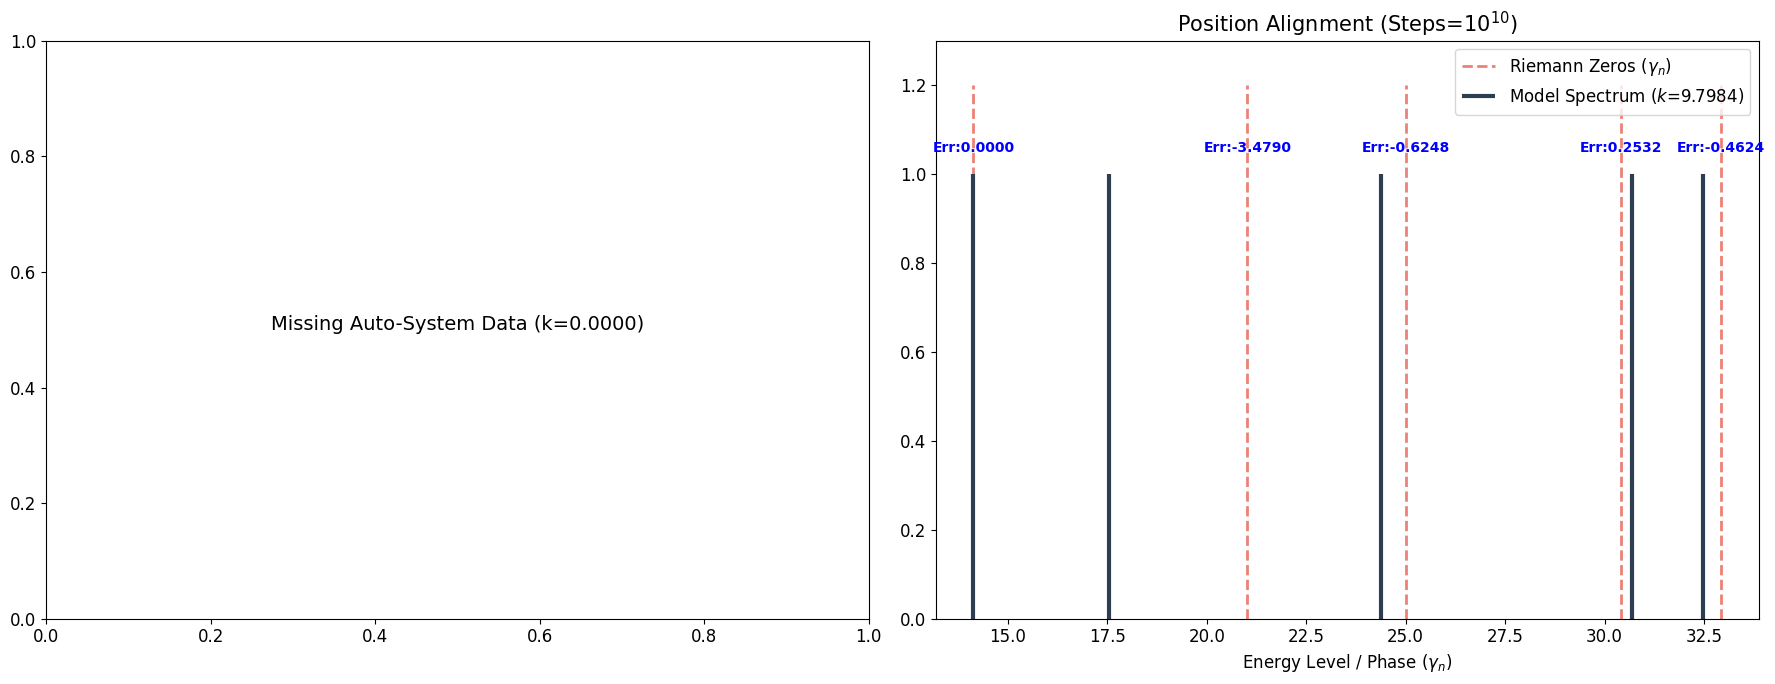

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. 配置参数与真实零点 ---
TRUE_GAMMAS = np.array([14.1347, 21.0220, 25.0108, 30.4248, 32.9350])
# 根据你扫描出的最优结果
best_ks = {
    "mode1": 4.7000,
    "mode2": 12.0927,
    "mode3": 11.8378,
    "mode4": 9.7984,
    "mode5": 9.7984
}

def plot_final_results():
    # 设置全局字体，确保 LaTeX 渲染美观
    plt.rcParams.update({'font.size': 12})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    # --- 2. 左图：GUE 统计 (自治系统极限验证) ---
    # 假设你有一个 res_k_0.0000_steps10t10.npy
    auto_file = 'res_k_0.0000_steps10t10.npy' 
    if os.path.exists(auto_file):
        phases_auto = np.load(auto_file)
        # 计算标准间距 s
        s = np.diff(phases_auto) / np.mean(np.diff(phases_auto))
        std_auto = np.std(s)
        
        # 使用 r"..." 原始字符串修正 SyntaxWarning
        ax1.hist(s, bins=60, density=True, alpha=0.6, color='#3498db', 
                 label=r'Auto-System ($\sigma$={:.4f})'.format(std_auto))
        
        s_theory = np.linspace(0, 4, 100)
        p_gue = (32 / np.pi**2) * (s_theory**2) * np.exp(-4 * s_theory**2 / np.pi)
        ax1.plot(s_theory, p_gue, 'r-', lw=3, label=r'Standard GUE Target ($\sigma$=0.422)')
        ax1.set_title('Spectral Statistics: The GUE Fingerprint', fontsize=15)
        ax1.set_xlabel(r'Normalized Spacing $s$')
        ax1.set_ylabel('Density')
        ax1.legend()
    else:
        ax1.text(0.5, 0.5, 'Missing Auto-System Data (k=0.0000)', ha='center', fontsize=14)

    # --- 3. 右图：零点对齐 (非自治系统暴力实锤) ---
    # 以模式 1 最优的 k=4.7000 作为展示基准
    target_k = 9.7984
    target_file = f'res_k_{target_k:.4f}_steps10t10.npy'
    
    if os.path.exists(target_file):
        phases_non_auto = np.load(target_file)
        # 对齐第一个零点进行缩放校准
        scaling = TRUE_GAMMAS[0] / phases_non_auto[0]
        sim_gammas = phases_non_auto[:5] * scaling
        
        # 使用 r"..." 原始字符串修正 SyntaxWarning
        ax2.vlines(TRUE_GAMMAS, 0, 1.2, colors='#e74c3c', linestyles='--', lw=2, 
                   label=r'Riemann Zeros ($\gamma_n$)', alpha=0.7)
        ax2.vlines(sim_gammas, 0, 1.0, colors='#2c3e50', linestyles='-', lw=3, 
                   label=r'Model Spectrum ($k$={:.4f})'.format(target_k))
        
        # 标注误差
        for i, (sim, true) in enumerate(zip(sim_gammas, TRUE_GAMMAS)):
            err = sim - true
            ax2.text(true, 1.05, r'Err:{:.4f}'.format(err), ha='center', fontsize=10, color='blue', fontweight='bold')
            
        ax2.set_title(r'Position Alignment (Steps=$10^{10}$)', fontsize=15)
        ax2.set_xlabel(r'Energy Level / Phase ($\gamma_n$)')
        ax2.set_ylim(0, 1.3)
        ax2.legend()
    else:
        ax2.text(0.5, 0.5, f'Missing Data for k={target_k:.4f}', ha='center', fontsize=14)

    plt.tight_layout()
    # 保存高分辨率科研图片
    plt.savefig('Riemann_Dynamics_Brute_Force.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    plot_final_results()